# Assignment 7: Creating and Fixing Mode Collapse in a GAN



## 1. Import Required Libraries

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cu130


## 2. Dataset and Training Settings

In [15]:
# Basic settings
Z_DIM = 100
BATCH_SIZE = 128
IMG_CHANNELS = 1
IMG_SIZE = 28
NUM_EPOCHS = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training device:", device)

# Fashion-MNIST images are scaled to [-1, 1]
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

fashion_data = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=preprocess
)

train_loader = torch.utils.data.DataLoader(
    fashion_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Number of training images:", len(fashion_data))

Training device: cuda
Number of training images: 60000


## 3. View a Few Real Images

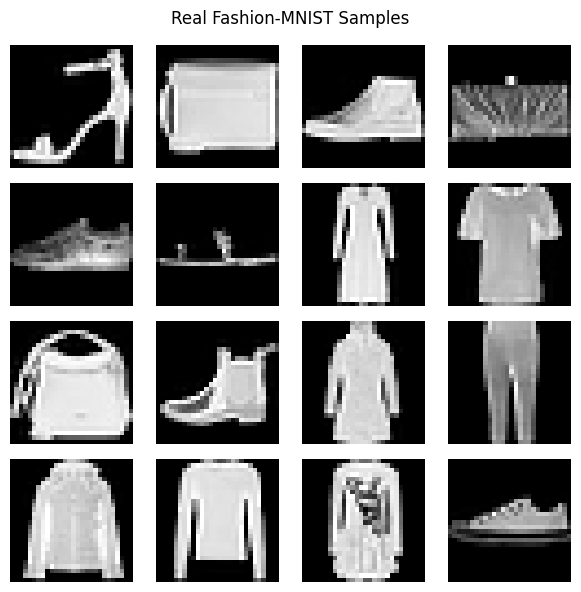

In [16]:
real_batch, _ = next(iter(train_loader))

plt.figure(figsize=(6, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = real_batch[i].squeeze().numpy()
    image = (image + 1) / 2
    plt.imshow(image, cmap="gray")
    plt.axis("off")

plt.suptitle("Real Fashion-MNIST Samples")
plt.tight_layout()
plt.show()

## 4. Original DCGAN Structure

The model below follows the same general DCGAN idea used in Assignment 4. Batch normalization is included here so that it can be compared with the intentionally unstable version later.

In [17]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.ConvTranspose2d(Z_DIM, 256, 4, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, IMG_CHANNELS, 4, 2, 3),
            nn.Tanh()
        )

    def forward(self, noise):
        return self.network(noise)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 3, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 1, 4, 1, 0),
            nn.Sigmoid()
        )

    def forward(self, image):
        return self.network(image).view(-1)


G = Generator().to(device)
D = Discriminator().to(device)

print("Generator and discriminator created.")

Generator and discriminator created.


# Part A — Deliberately Creating an Unstable GAN

## 5. Changes Made to Encourage Mode Collapse

For the first experiment, the generator is made much smaller and its batch-normalization layers are removed. At the same time, a learning rate much larger than the original Assignment 4 value is used.

These changes make the generator updates more aggressive and reduce its ability to maintain a wide variety of generated samples.

In [18]:
class CollapsedGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        # Much smaller capacity than the original generator
        # Batch normalization is intentionally removed.
        self.network = nn.Sequential(
            nn.ConvTranspose2d(Z_DIM, 64, 4, 1, 0),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 8, 4, 2, 1),
            nn.ReLU(True),

            nn.ConvTranspose2d(8, IMG_CHANNELS, 4, 2, 3),
            nn.Tanh()
        )

    def forward(self, noise):
        return self.network(noise)


G_bad = CollapsedGenerator().to(device)
D_bad = Discriminator().to(device)

criterion = nn.BCELoss()

# Much larger learning rate than the stable Assignment 4 setup
BAD_LR = 0.002

g_bad_optimizer = optim.Adam(
    G_bad.parameters(),
    lr=BAD_LR,
    betas=(0.5, 0.999)
)

d_bad_optimizer = optim.Adam(
    D_bad.parameters(),
    lr=BAD_LR,
    betas=(0.5, 0.999)
)

print("Unstable model is ready.")
print("Generator learning rate:", BAD_LR)
print("Batch normalization in generator: removed")
print("Generator capacity: reduced")

Unstable model is ready.
Generator learning rate: 0.002
Batch normalization in generator: removed
Generator capacity: reduced


## 6. Train the Unstable Model

Epoch 01/20 | D Loss: 0.5189 | G Loss: 4.6312
Epoch 02/20 | D Loss: 0.4966 | G Loss: 4.1426
Epoch 03/20 | D Loss: 0.4793 | G Loss: 3.9603
Epoch 04/20 | D Loss: 0.4845 | G Loss: 4.0244
Epoch 05/20 | D Loss: 0.4047 | G Loss: 4.2542


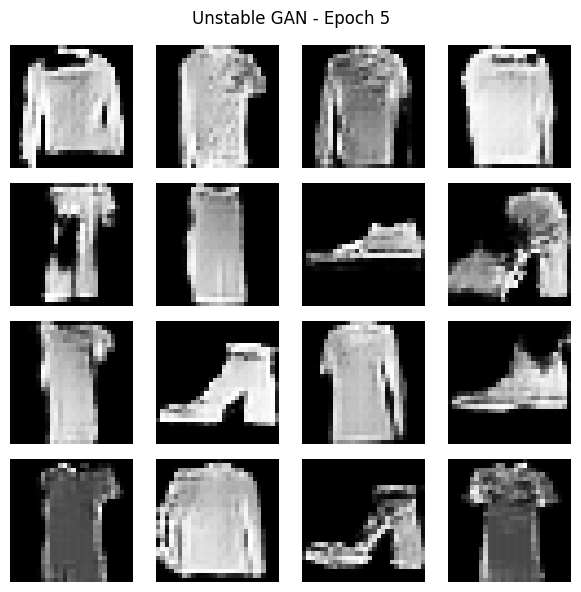

Epoch 06/20 | D Loss: 0.3875 | G Loss: 4.2072
Epoch 07/20 | D Loss: 0.2430 | G Loss: 4.7698
Epoch 08/20 | D Loss: 0.4343 | G Loss: 4.5031
Epoch 09/20 | D Loss: 0.2652 | G Loss: 4.7934
Epoch 10/20 | D Loss: 0.3355 | G Loss: 4.7517


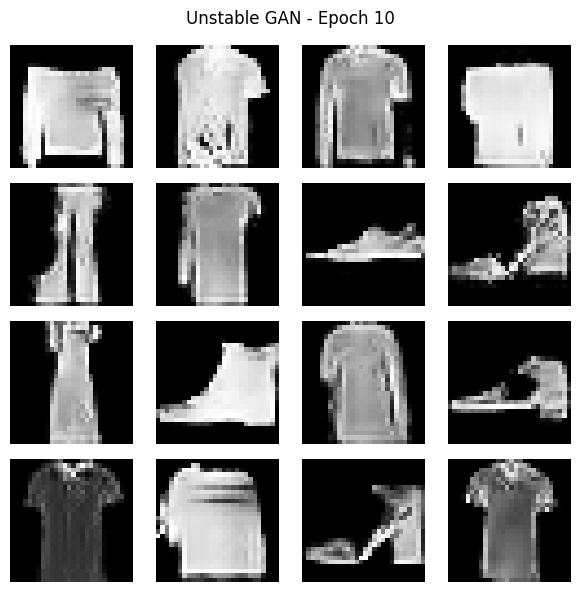

Epoch 11/20 | D Loss: 0.3436 | G Loss: 4.7573
Epoch 12/20 | D Loss: 0.3058 | G Loss: 5.2160
Epoch 13/20 | D Loss: 0.3252 | G Loss: 4.8209
Epoch 14/20 | D Loss: 0.2240 | G Loss: 5.3398
Epoch 15/20 | D Loss: 0.1662 | G Loss: 5.5712


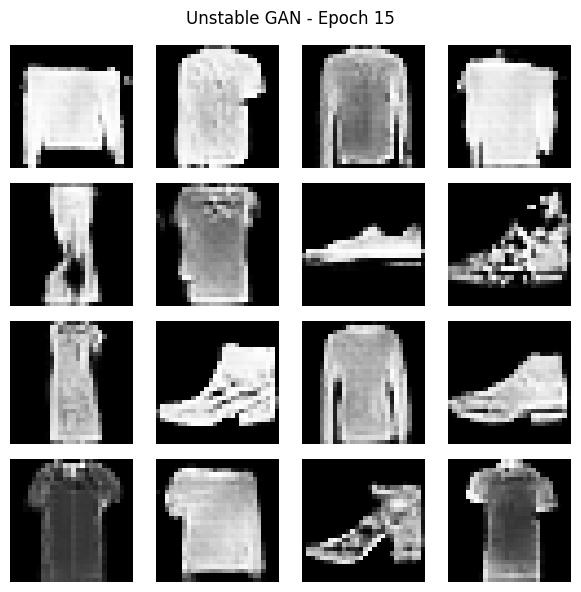

Epoch 16/20 | D Loss: 0.0907 | G Loss: 5.9721
Epoch 17/20 | D Loss: 0.2561 | G Loss: 6.1235
Epoch 18/20 | D Loss: 0.2474 | G Loss: 5.5725
Epoch 19/20 | D Loss: 0.1257 | G Loss: 6.0704
Epoch 20/20 | D Loss: 0.0828 | G Loss: 6.2762


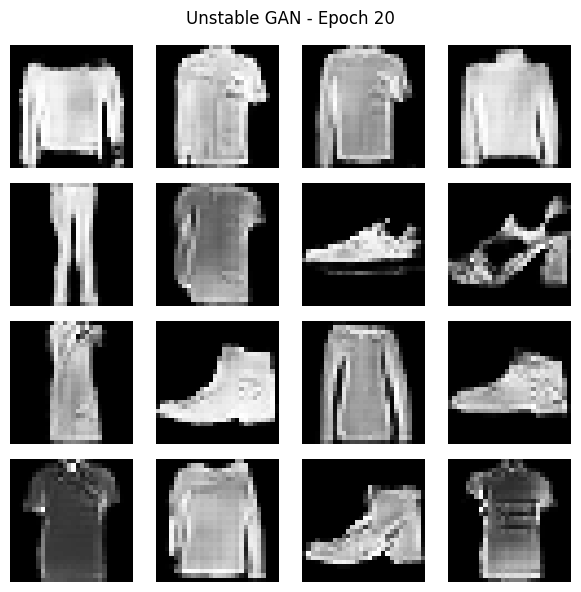

In [19]:
bad_g_history = []
bad_d_history = []

preview_noise = torch.randn(16, Z_DIM, 1, 1, device=device)

for epoch in range(NUM_EPOCHS):
    total_g = 0.0
    total_d = 0.0

    for real_data, _ in train_loader:
        real_data = real_data.to(device)
        batch_size = real_data.size(0)

        real_targets = torch.ones(batch_size, device=device)
        fake_targets = torch.zeros(batch_size, device=device)

        # -------------------------
        # Discriminator update
        # -------------------------
        d_bad_optimizer.zero_grad()

        real_output = D_bad(real_data)
        real_loss = criterion(real_output, real_targets)

        noise = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
        fake_data = G_bad(noise)

        fake_output = D_bad(fake_data.detach())
        fake_loss = criterion(fake_output, fake_targets)

        d_loss = real_loss + fake_loss
        d_loss.backward()
        d_bad_optimizer.step()

        # -------------------------
        # Generator update
        # -------------------------
        g_bad_optimizer.zero_grad()

        output_for_g = D_bad(fake_data)
        g_loss = criterion(output_for_g, real_targets)

        g_loss.backward()
        g_bad_optimizer.step()

        total_d += d_loss.item()
        total_g += g_loss.item()

    avg_d = total_d / len(train_loader)
    avg_g = total_g / len(train_loader)

    bad_d_history.append(avg_d)
    bad_g_history.append(avg_g)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}"
    )

    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            samples = G_bad(preview_noise)

        plt.figure(figsize=(6, 6))

        for i in range(16):
            plt.subplot(4, 4, i + 1)
            image = samples[i].squeeze().cpu().numpy()
            image = (image + 1) / 2
            plt.imshow(image, cmap="gray")
            plt.axis("off")

        plt.suptitle(f"Unstable GAN - Epoch {epoch + 1}")
        plt.tight_layout()
        plt.savefig(f"assignment7_broken_epoch_{epoch + 1}.png")
        plt.show()

## 7. Broken / Collapsed Output

The image grid saved above is the required **broken-output screenshot**.

Look for the following signs:

- several generated images having almost the same structure,
- repeated clothing shapes,
- loss of variety between samples,
- noisy or poorly defined outputs.

The exact severity can depend on the hardware and random initialization.

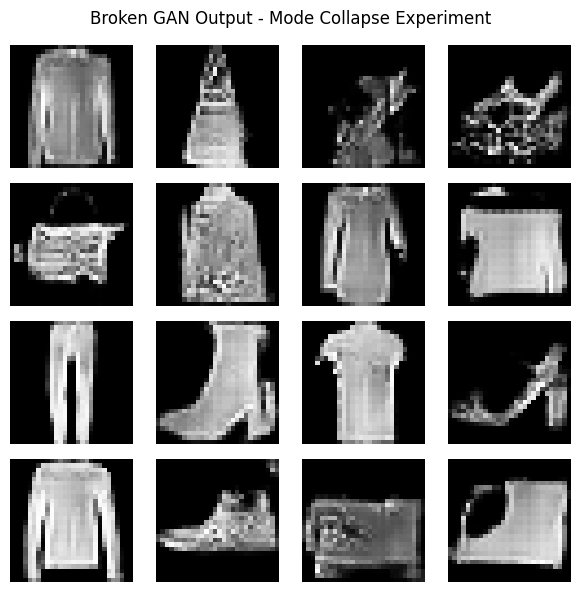

In [20]:
# Final output from the unstable model
with torch.no_grad():
    broken_images = G_bad(torch.randn(16, Z_DIM, 1, 1, device=device))

plt.figure(figsize=(6, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = broken_images[i].squeeze().cpu().numpy()
    image = (image + 1) / 2
    plt.imshow(image, cmap="gray")
    plt.axis("off")

plt.suptitle("Broken GAN Output - Mode Collapse Experiment")
plt.tight_layout()
plt.savefig("assignment7_broken_output.png")
plt.show()

# Part B — Improving the Training

## 8. Using Different Learning Rates

To improve the unstable training, the model capacity is kept the same but the learning rates are changed.

The discriminator is allowed to learn slightly faster, while the generator uses a smaller learning rate. This makes the generator updates less aggressive and can help it avoid repeatedly moving toward the same solution.

In [21]:
G_fix = CollapsedGenerator().to(device)
D_fix = Discriminator().to(device)

# Smaller generator learning rate and a moderate discriminator rate
G_LR = 0.0002
D_LR = 0.0005

g_fix_optimizer = optim.Adam(
    G_fix.parameters(),
    lr=G_LR,
    betas=(0.5, 0.999)
)

d_fix_optimizer = optim.Adam(
    D_fix.parameters(),
    lr=D_LR,
    betas=(0.5, 0.999)
)

criterion_fix = nn.BCELoss()

print("Improved training setup created.")
print("Generator LR:", G_LR)
print("Discriminator LR:", D_LR)

Improved training setup created.
Generator LR: 0.0002
Discriminator LR: 0.0005


## 9. Retrain the Model

Epoch 01/20 | D Loss: 0.0558 | G Loss: 7.7868
Epoch 02/20 | D Loss: 0.1215 | G Loss: 5.8345
Epoch 03/20 | D Loss: 0.0975 | G Loss: 6.3233
Epoch 04/20 | D Loss: 0.0382 | G Loss: 6.4542
Epoch 05/20 | D Loss: 0.3006 | G Loss: 6.4978


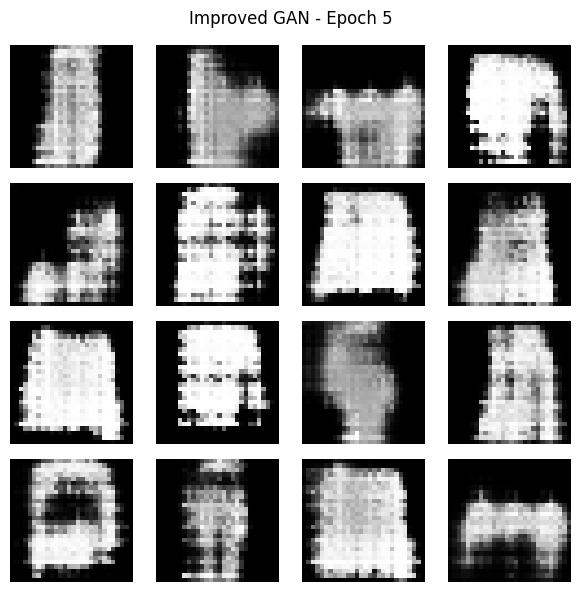

Epoch 06/20 | D Loss: 0.0287 | G Loss: 6.7582
Epoch 07/20 | D Loss: 0.6300 | G Loss: 6.5361
Epoch 08/20 | D Loss: 0.2060 | G Loss: 5.8125
Epoch 09/20 | D Loss: 0.0254 | G Loss: 6.5920
Epoch 10/20 | D Loss: 0.1542 | G Loss: 6.3646


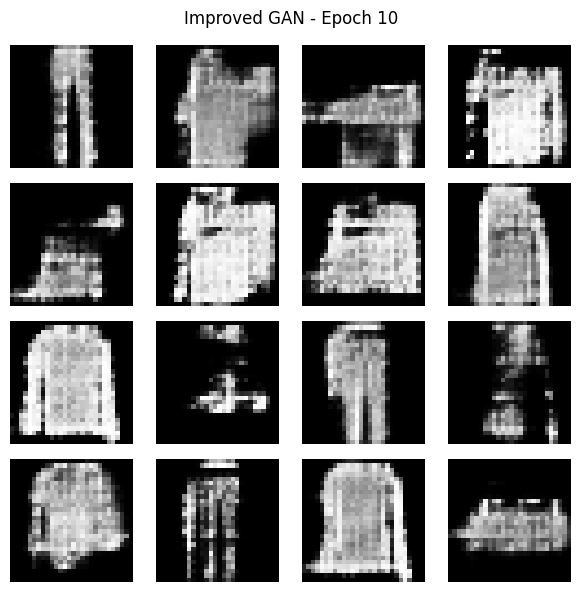

Epoch 11/20 | D Loss: 0.0800 | G Loss: 6.2525
Epoch 12/20 | D Loss: 0.3359 | G Loss: 6.5567
Epoch 13/20 | D Loss: 0.0564 | G Loss: 6.1463
Epoch 14/20 | D Loss: 0.1086 | G Loss: 6.1376
Epoch 15/20 | D Loss: 0.1480 | G Loss: 5.8811


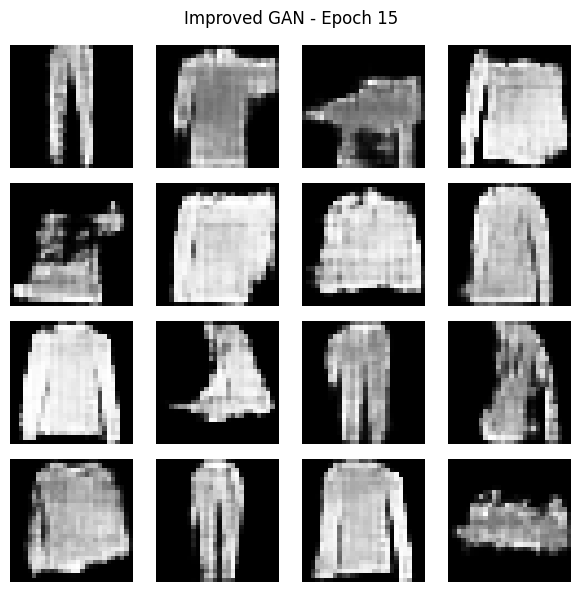

Epoch 16/20 | D Loss: 0.0285 | G Loss: 6.6202
Epoch 17/20 | D Loss: 0.1488 | G Loss: 6.0591
Epoch 18/20 | D Loss: 0.0244 | G Loss: 6.6207
Epoch 19/20 | D Loss: 0.1643 | G Loss: 6.1471
Epoch 20/20 | D Loss: 0.2823 | G Loss: 6.4378


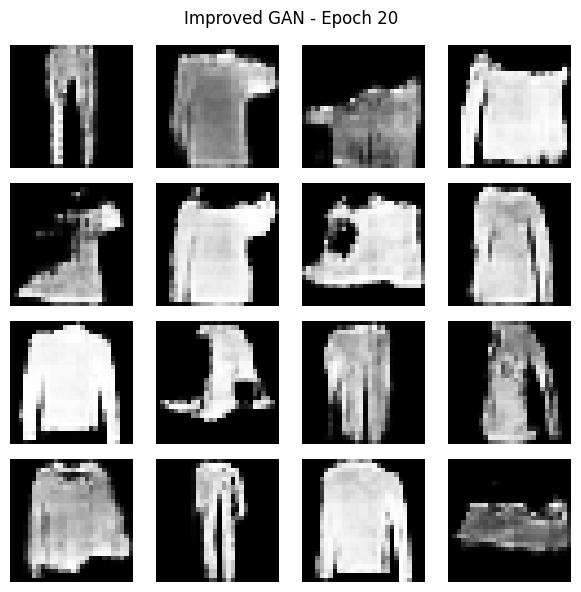

In [22]:
fixed_g_history = []
fixed_d_history = []

for epoch in range(NUM_EPOCHS):
    total_g = 0.0
    total_d = 0.0

    for real_data, _ in train_loader:
        real_data = real_data.to(device)
        batch_size = real_data.size(0)

        real_targets = torch.ones(batch_size, device=device)
        fake_targets = torch.zeros(batch_size, device=device)

        # Discriminator
        d_fix_optimizer.zero_grad()

        real_output = D_fix(real_data)
        real_loss = criterion_fix(real_output, real_targets)

        noise = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
        fake_data = G_fix(noise)

        fake_output = D_fix(fake_data.detach())
        fake_loss = criterion_fix(fake_output, fake_targets)

        d_loss = real_loss + fake_loss
        d_loss.backward()
        d_fix_optimizer.step()

        # Generator
        g_fix_optimizer.zero_grad()

        output_for_g = D_fix(fake_data)
        g_loss = criterion_fix(output_for_g, real_targets)

        g_loss.backward()
        g_fix_optimizer.step()

        total_d += d_loss.item()
        total_g += g_loss.item()

    avg_d = total_d / len(train_loader)
    avg_g = total_g / len(train_loader)

    fixed_d_history.append(avg_d)
    fixed_g_history.append(avg_g)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}"
    )

    if (epoch + 1) % 5 == 0:
        with torch.no_grad():
            samples = G_fix(preview_noise)

        plt.figure(figsize=(6, 6))

        for i in range(16):
            plt.subplot(4, 4, i + 1)
            image = samples[i].squeeze().cpu().numpy()
            image = (image + 1) / 2
            plt.imshow(image, cmap="gray")
            plt.axis("off")

        plt.suptitle(f"Improved GAN - Epoch {epoch + 1}")
        plt.tight_layout()
        plt.savefig(f"assignment7_improved_epoch_{epoch + 1}.png")
        plt.show()

## 10. Improved Output

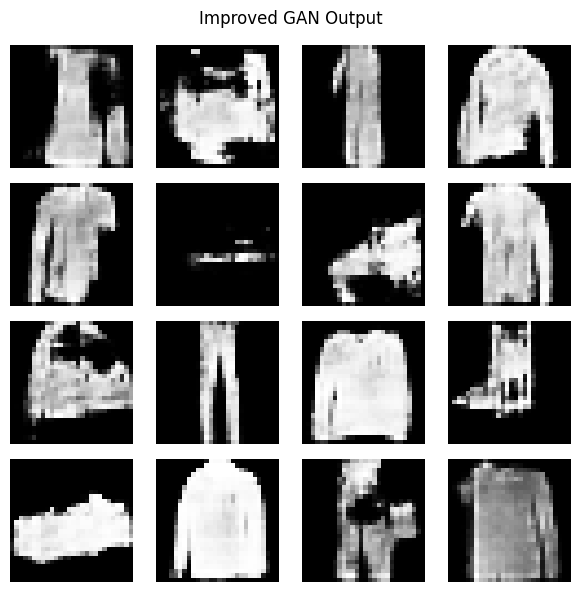

In [23]:
with torch.no_grad():
    improved_images = G_fix(torch.randn(16, Z_DIM, 1, 1, device=device))

plt.figure(figsize=(6, 6))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = improved_images[i].squeeze().cpu().numpy()
    image = (image + 1) / 2
    plt.imshow(image, cmap="gray")
    plt.axis("off")

plt.suptitle("Improved GAN Output")
plt.tight_layout()
plt.savefig("assignment7_improved_output.png")
plt.show()

## 11. Compare the Training Curves

The curves are included to see whether the second experiment is less unstable than the first one.

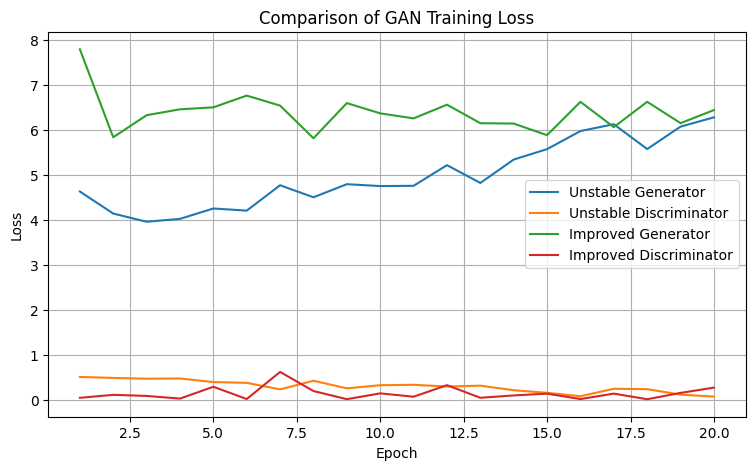

In [24]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, bad_g_history, label="Unstable Generator")
plt.plot(epochs, bad_d_history, label="Unstable Discriminator")
plt.plot(epochs, fixed_g_history, label="Improved Generator")
plt.plot(epochs, fixed_d_history, label="Improved Discriminator")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Comparison of GAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

# Written Explanation

### 1. What modification caused the model to perform poorly?

The generator was deliberately given much less capacity, its batch-normalization layers were removed, and the learning rate was increased from the original DCGAN value. These changes made the generator updates more aggressive and made the training less stable. As a result, the generator had difficulty maintaining different types of Fashion-MNIST samples.

### 2. What did the generated images look like?

In the unstable experiment, the generated samples became less diverse. Some images showed very similar shapes or repeated patterns instead of representing a wide range of clothing items. The outputs could also contain noisy or unclear regions. This behavior is associated with mode collapse because the generator is producing a limited set of patterns.

### 3. Which technique was used to improve the model?

Different learning rates were used for the generator and discriminator. The generator was given a smaller learning rate of `0.0002`, while the discriminator used `0.0005`. This reduced the size of the generator's updates while allowing the discriminator to learn at a moderate rate.

### 4. Did the solution improve the output? Why?

The second experiment should show better variety and more stable-looking samples compared with the deliberately unstable run. A smaller generator learning rate prevents very large changes during training, so the generator has a better chance of learning different Fashion-MNIST patterns instead of repeatedly producing a similar output.

The exact amount of improvement depends on the random initialization and the training hardware, so the generated image grids should be used as the final visual evidence.